In [8]:
import pandas as pd
import numpy as np
import warnings 
import matplotlib.pyplot as plt
import koreanize_matplotlib
warnings.filterwarnings('ignore')

#### Keras를 이용한 손글씩 인식

In [9]:
# 데이터 불러오기

train = pd.read_csv('../Data/train_20k.csv', header=None)
test = pd.read_csv('../Data/test_1k.csv', header=None)
print(train.head())
print(test.head())

   0    1    2    3    4    5    6    7    8    9    ...  775  776  777  778  \
0    5    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
1    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2    4    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
3    1    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
4    9    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   

   779  780  781  782  783  784  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  
2    0    0    0    0    0    0  
3    0    0    0    0    0    0  
4    0    0    0    0    0    0  

[5 rows x 785 columns]
   0    1    2    3    4    5    6    7    8    9    ...  775  776  777  778  \
0    7    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
1    2    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2    1    0    0    0    0    0    0    0    0    0

In [10]:
# 결측치
train.isnull().sum().sum()


np.int64(0)

In [11]:
# train의 0번(Target)의 분포 확인
train_label = train[0]
sorted(train_label.value_counts())

[1776, 1922, 1929, 1945, 1971, 1994, 2014, 2076, 2093, 2281]

In [12]:
1776/2281


0.7786058746163963

#### Target(0), Feature(1~784) 분리하고 정규화하기


In [30]:
train_label = train.loc[:,train.columns == 0]
train_data = train.loc[:,train.columns != 0]
train_data = train_data / 255

test_label = test[0]
test_data = test.iloc[:,1:]
test_data = test_data / 255

----
#### Deep Learning Model 만들기
- 입력층 : 784
- 은닉층 : 1024, activation - relu 
- 출력층 : 10, activation - softmax
- complie : loss(sparse_categorical_crossentropy), optimizer - adam

In [31]:
from tensorflow import keras
from tensorflow.keras.layers import Input

In [32]:
model = keras.Sequential()
model.add(Input(shape=(784,)))
model.add(keras.layers.Dense(784, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'],
)

hist = model.fit(
    np.array(train_data),
    np.array(train_label),
    epochs = 50,
)

Epoch 1/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9137 - loss: 0.2964
Epoch 2/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9652 - loss: 0.1193
Epoch 3/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9793 - loss: 0.0700
Epoch 4/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9878 - loss: 0.0432
Epoch 5/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9911 - loss: 0.0287
Epoch 6/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9934 - loss: 0.0227
Epoch 7/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9957 - loss: 0.0151
Epoch 8/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9948 - loss: 0.0173
Epoch 9/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9960 - loss: 0.0111
Epoch 10/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9976 - loss: 0.0088
Epoch 11/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9948 - loss: 0.0160
Epoch 12/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [16]:
# Train Data로 평가
scores = model.evaluate(train_data, train_label)
print("loss : ", scores[0])
print("accuracy : ", scores[1])

626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 777us/step - accuracy: 1.0000 - loss: 5.0048e-08
loss :  5.004751102433147e-08
accuracy :  1.0


In [ ]:
# Test Data로 평가
scores = model.evaluate(test_data, test_label)
print("loss : ", scores[0])
print("accuracy : ", scores[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9750 - loss: 0.1638
loss :  0.163797989487648
accuracy :  0.9750249981880188


In [18]:
# 훈련 및 과정 대한 history보기
hist.history.keys()

dict_keys(['accuracy', 'loss'])

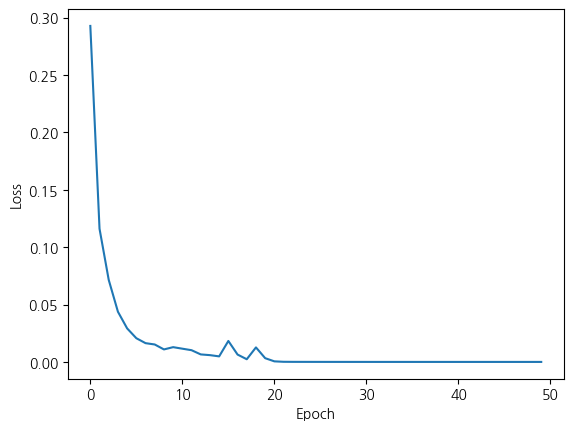

In [19]:
#### 손실 곡선
plt.plot(hist.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

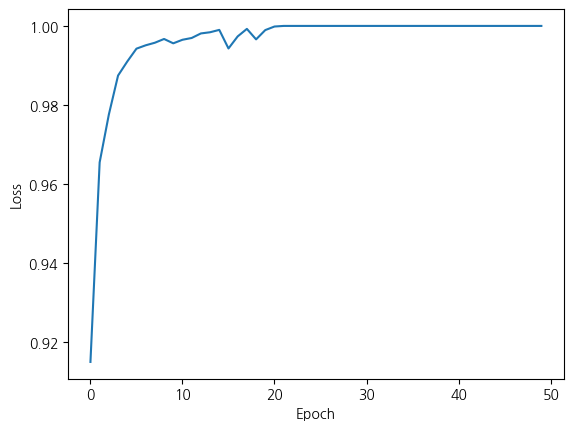

In [24]:
#### 정확도 곡선
plt.plot(hist.history['accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

---
#### test_data로 predict 해보기

In [34]:
pred = model.predict(test_data)
print('test_label :',test_label[:10])
print('pred :',np.argmax(pred[:10], axis=1))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
test_label : 0    7
1    2
2    1
3    0
4    4
5    1
6    4
7    9
8    5
9    9
Name: 0, dtype: int64
pred : [7 2 1 0 4 1 4 9 5 9]


In [35]:
pred[:10]

array([[2.49844180e-25, 2.03063563e-27, 5.78996742e-22, 4.33522474e-16,
        2.89781639e-37, 2.18762907e-29, 3.29558830e-38, 1.00000000e+00,
        8.42247190e-26, 1.04423510e-24],
       [7.75272468e-26, 2.23741403e-15, 1.00000000e+00, 4.55528771e-15,
        0.00000000e+00, 1.08285192e-21, 9.70564996e-24, 1.37099916e-31,
        2.81228219e-23, 2.20335080e-35],
       [4.23936284e-21, 1.00000000e+00, 9.37018463e-09, 2.39737493e-15,
        9.66078563e-13, 2.36712293e-15, 6.50018369e-14, 1.55657942e-09,
        2.89116890e-11, 1.42850201e-19],
       [1.00000000e+00, 8.08664761e-29, 1.38638766e-16, 5.55366597e-23,
        4.03098653e-25, 3.44911445e-22, 6.13200502e-16, 1.60108285e-15,
        4.13142595e-27, 2.32196267e-19],
       [8.89232972e-21, 3.09375544e-25, 2.82020283e-21, 4.56262601e-23,
        1.00000000e+00, 1.82251777e-24, 1.42030418e-17, 6.31575665e-16,
        1.43960859e-17, 5.77088488e-10],
       [1.74956946e-27, 1.00000000e+00, 2.05488922e-16, 1.93575418e-20,
   